In [30]:
import numpy as np
import pandas as pd

In [31]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [32]:
df.dropna(inplace=True)

In [33]:
print(df['clean_comment'].isna().sum())

0


In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df = df[~(df['clean_comment'].str.strip() == '')]

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [7]:
# Ensure necessary NLTK data is downloaded
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
# Define the preprocessing function
def preprocess_comment(comment):
    # Convert to lowercase
    comment = comment.lower()

    # Remove trailing and leading whitespaces
    comment = comment.strip()

    # Remove newline characters
    comment = re.sub(r'\n', ' ', comment)

    # Remove non-alphanumeric characters, except punctuation
    comment = re.sub(r'[^A-Za-z0-9\s!?.,]', '', comment)

    # Remove stopwords but retain important ones for sentiment analysis
    stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
    comment = ' '.join([word for word in comment.split() if word not in stop_words])

    # Lemmatize the words
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment

In [9]:
# Apply the preprocessing function to the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)

In [10]:
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [11]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Step 1: Split the data FIRST to avoid data leakage
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_comment'],
    df['category'],
    test_size=0.2,
    random_state=42,
    stratify=df['category']
)

# Step 2: Vectorize using Bag of Words (CountVectorizer)
# FIT ONLY on training data to prevent data leakage
vectorizer = CountVectorizer(max_features=10000)

In [13]:
X_train = vectorizer.fit_transform(X_train_raw).toarray()
X_test = vectorizer.transform(X_test_raw).toarray()

In [24]:
# Step 2: Set up the MLflow tracking server
import mlflow
# Step 2: Set up the MLflow tracking server
mlflow.set_tracking_uri("https://dagshub.com/Roy7721/yt_comment_analysis.mlflow")


import os

os.environ["MLFLOW_TRACKING_USERNAME"] = "Roy7721"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "bc912b7d58bd2aca05abdc192e010414493a3886"

In [26]:
# Set or create an experiment
mlflow.set_experiment("Baseline")

2026/07/20 21:11:22 INFO mlflow.tracking.fluent: Experiment with name 'Baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/a2a989d8b92a49aaae91f8b25189b9f1', creation_time=1784560283075, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1784560283075, lifecycle_stage='active', name='Baseline', tags={}, trace_location=None, workspace='default'>

2026/07/20 21:21:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForest_Baseline_TrainTestSplit at: https://dagshub.com/Roy7721/yt_comment_analysis.mlflow/#/experiments/4/runs/a2ea8b0284914e3b930da21135bf7d0a
🧪 View experiment at: https://dagshub.com/Roy7721/yt_comment_analysis.mlflow/#/experiments/4
Accuracy: 0.6428862617203425


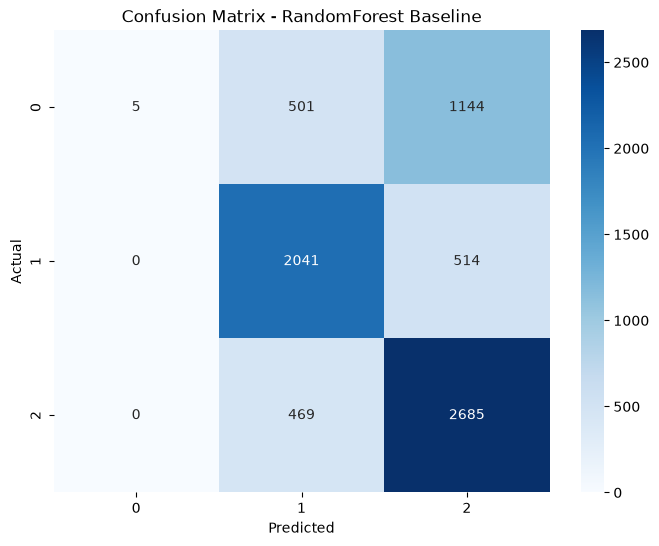

In [27]:
# Step 3: Train Random Forest baseline model
with mlflow.start_run() as run:
    # Log a description for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    # Add a description
    mlflow.set_tag("description", "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with proper train-test split (no data leakage)")

    # Log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    # Log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - RandomForest Baseline")

    # Save and log the confusion matrix plot
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    # Log the Random Forest model
    mlflow.sklearn.log_model(model, "random_forest_model")

    # Optionally log the dataset itself (if it's small enough)
    df.to_csv("dataset.csv", index=False)
    mlflow.log_artifact("dataset.csv")

# Display final accuracy
print(f"Accuracy: {accuracy}")

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       1.00      0.00      0.01      1650
           0       0.68      0.80      0.73      2555
           1       0.62      0.85      0.72      3154

    accuracy                           0.64      7359
   macro avg       0.77      0.55      0.49      7359
weighted avg       0.72      0.64      0.56      7359



In [34]:
new_data = pd.read_csv('dataset.csv').head()

In [35]:
print(new_data['clean_comment'].isna().sum())

0
